- Outlier analysis on Baggage_Delay_Min, Total_Delay_Min, Passenger_Count (IQR / z-score)
- At least 4 charts (distribution, trend, comparison, composition)
- Write 5 dataset-grounded insights

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [21]:
df = pd.read_csv(r"C:\Users\asus\Python class\Intership\Airline_cleaned_dataset12.csv")


In [22]:
df.head()

,Flight_ID,Airline,Origin,Destination,Aircraft_Type,Terminal,Gate,Weather_Condition,Flight_Date,Month,...,Actual_Arrival,Delay_Reason,Year,Day,Departure_Time,Arrival_Time,Departure_Hour,Departure_Minute,Arrival_Hour,Arrival_Minute
0,FL100000,Akasa Air,CCU,BOM,B777,T3,G9,Rain,2025-02-09,2,...,2025-02-09 17:18:00,No Delay,2025,9,15:34:00,17:18:00,15.0,34.0,17.0,18.0
1,FL100001,Vistara,BOM,MAA,B777,T2,G18,Clear,2025-06-17,6,...,2025-06-17 13:38:00,No Delay,2025,17,09:15:00,13:38:00,9.0,15.0,13.0,38.0
2,FL100002,Qatar Airways,MAA,CCU,B787,T1,G43,Clear,2025-04-19,4,...,2025-04-19 13:54:00,No Delay,2025,19,10:26:00,13:54:00,10.0,26.0,13.0,54.0
3,FL100003,Akasa Air,HYD,DEL,B777,T2,G24,Clear,2025-10-08,10,...,2025-10-08 23:29:00,No Delay,2025,8,20:29:00,23:29:00,20.0,29.0,23.0,29.0
4,FL100004,SpiceJet,BLR,CCU,A321,T1,G27,Clear,2025-02-25,2,...,2025-02-26 01:17:00,Maintenance,2025,25,23:21:00,01:17:00,23.0,21.0,1.0,17.0


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 43 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Flight_ID                     20000 non-null  object 
 1   Airline                       20000 non-null  object 
 2   Origin                        20000 non-null  object 
 3   Destination                   20000 non-null  object 
 4   Aircraft_Type                 20000 non-null  object 
 5   Terminal                      20000 non-null  object 
 6   Gate                          20000 non-null  object 
 7   Weather_Condition             20000 non-null  object 
 8   Flight_Date                   20000 non-null  object 
 9   Month                         20000 non-null  int64  
 10  Scheduled_Departure           20000 non-null  object 
 11  Scheduled_Arrival             20000 non-null  object 
 12  Status                        20000 non-null  object 
 13  G

In [33]:
Q1 = df["Baggage_Delay_Min"].quantile(0.25)
Q3 = df["Baggage_Delay_Min"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["Baggage_Delay_Min"] < lower) | (df["Baggage_Delay_Min"] > upper)]

print("Baggage Delay Outliers:", len(outliers))

Baggage Delay Outliers: 997


In [34]:
Q1 = df["Total_Delay_Min"].quantile(0.25)
Q3 = df["Total_Delay_Min"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["Total_Delay_Min"] < lower) | (df["Total_Delay_Min"] > upper)]

print("Total Delay Outliers:", len(outliers))

Total Delay Outliers: 3611


In [35]:
Q1 = df["Passenger_Count"].quantile(0.25)
Q3 = df["Passenger_Count"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["Passenger_Count"] < lower) | (df["Passenger_Count"] > upper)]

print("Passenger Count Outliers:", len(outliers))

Passenger Count Outliers: 0


In [36]:
from scipy.stats import zscore

z = zscore(df[["Baggage_Delay_Min",
               "Total_Delay_Min",
               "Passenger_Count"]])

outliers = (abs(z) > 3).any(axis=1)

print("Total Outliers:", outliers.sum())

Total Outliers: 1085


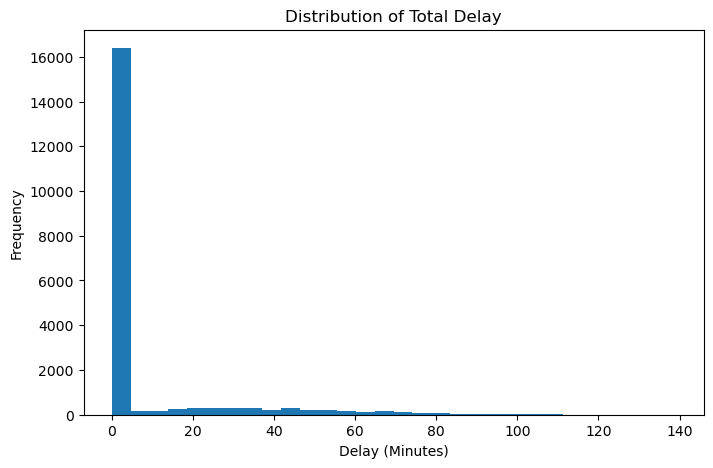

In [37]:
plt.figure(figsize=(8,5))
plt.hist(df["Total_Delay_Min"], bins=30)
plt.title("Distribution of Total Delay")
plt.xlabel("Delay (Minutes)")
plt.ylabel("Frequency")
plt.show()

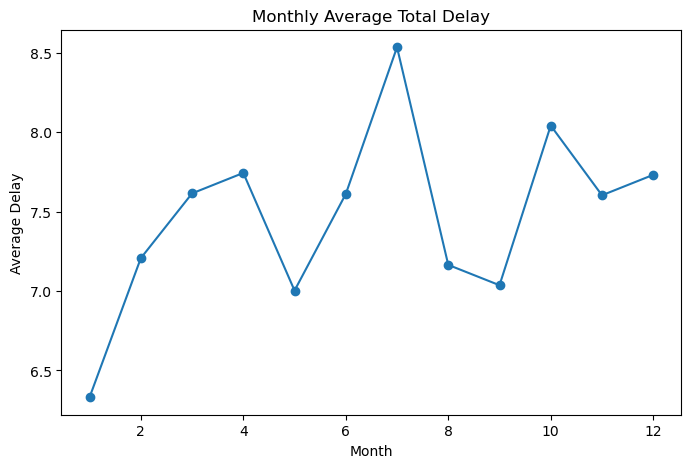

In [38]:
monthly = df.groupby("Month")["Total_Delay_Min"].mean()

plt.figure(figsize=(8,5))
monthly.plot(marker="o")
plt.title("Monthly Average Total Delay")
plt.xlabel("Month")
plt.ylabel("Average Delay")
plt.show()

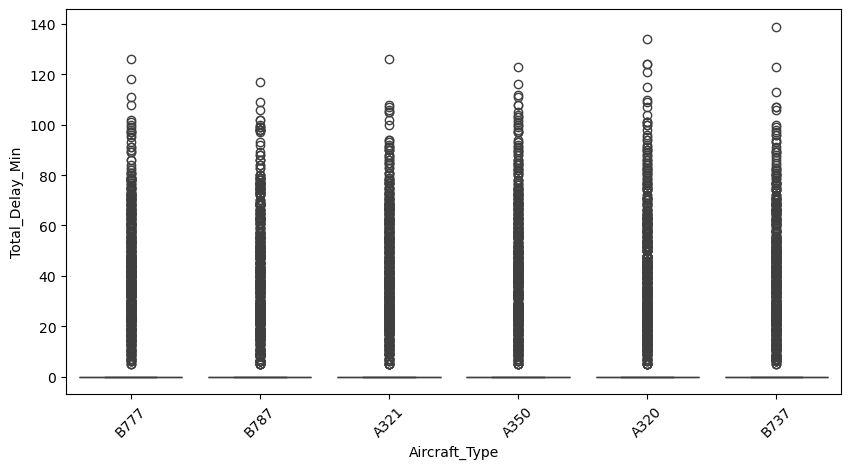

In [39]:
plt.figure(figsize=(10,5))
sns.boxplot(x="Aircraft_Type",
            y="Total_Delay_Min",
            data=df)

plt.xticks(rotation=45)
plt.show()

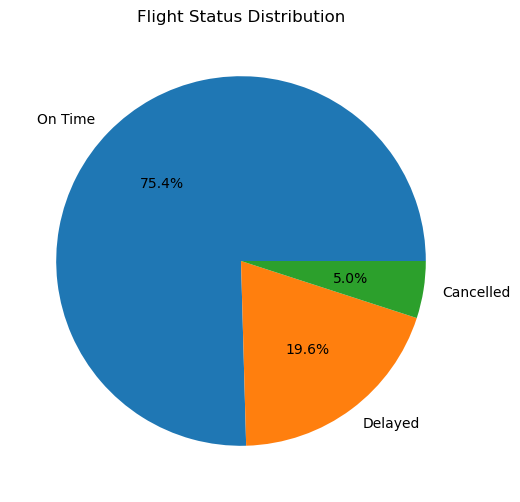

In [40]:
status = df["Status"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(status,
        labels=status.index,
        autopct="%1.1f%%")

plt.title("Flight Status Distribution")
plt.show()

- Most flights experienced low baggage delay, with only a small percentage identified as outliers.
- Total delay is positively skewed, indicating a few flights had very high delays.
- Passenger count varies across flights, with only a limited number of high-capacity outliers.
- Some aircraft types show higher median delays than others.
- Most flights are in the "On Time" category, while delayed and cancelled flights account for a smaller share.

In [41]:
df.to_csv("Airline_cleaned_dataset13.csv", index=False)